In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import our loader
from loader_ir import (
    load_all_ir_data, 
    print_data_summary,
    baseline_correction,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Define data path
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


## 2. Data Overview

In [3]:
# Print comprehensive data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [4]:
# Extract key arrays for easier access
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']
contaminant_labels = data['contaminant_labels']
filenames = data['filenames']
plastic_types = data['plastic_types']
contaminants_list = data['contaminants_list']

print(f"Spectra matrix shape: {spectra.shape}")
print(f"  - {spectra.shape[0]} samples")
print(f"  - {spectra.shape[1]} wavenumber points per spectrum")
print(f"\nWavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"Wavenumber resolution: {np.mean(np.diff(wavenumbers)):.2f} cm⁻¹")
print(f"\nPlastic labels shape: {plastic_labels.shape}")
print(f"Contaminant labels shape: {contaminant_labels.shape}")

Spectra matrix shape: (788, 7469)
  - 788 samples
  - 7469 wavenumber points per spectrum

Wavenumber range: 399.7 - 4000.2 cm⁻¹
Wavenumber resolution: 0.48 cm⁻¹

Plastic labels shape: (788, 4)
Contaminant labels shape: (788, 6)


In [5]:
# Check for interpolated files
if 'interpolated_count' in data:
    print(f"Files that required interpolation: {data['interpolated_count']}")
    if data['interpolated_count'] > 0 and len(data['interpolated_files']) <= 10:
        print("\nInterpolated files:")
        for fname, orig_points in data['interpolated_files']:
            print(f"  - {fname}: {orig_points} -> {len(wavenumbers)} points")

Files that required interpolation: 256


## 3. Label Distribution

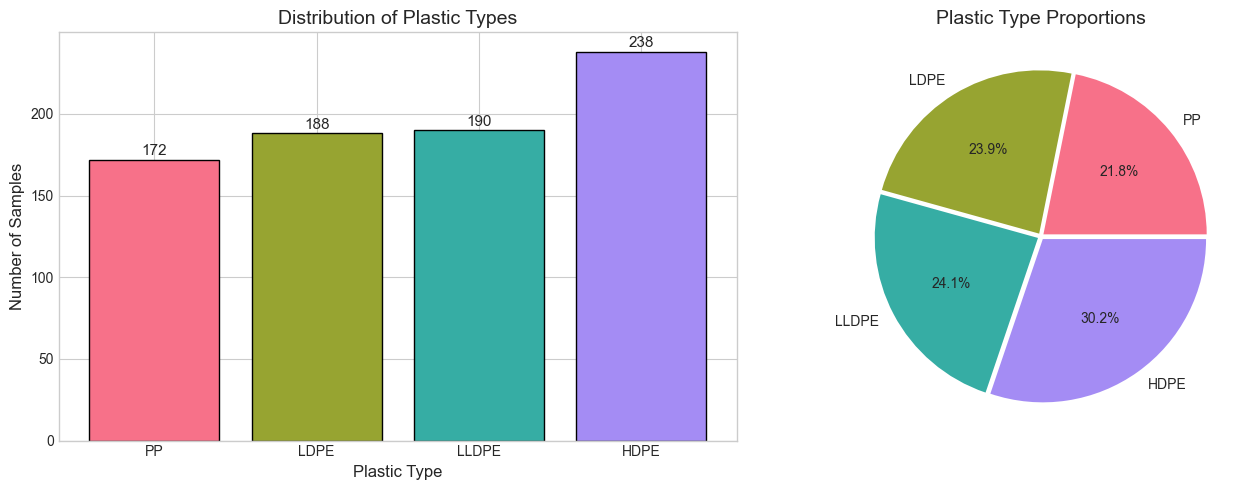

In [6]:
# Plastic type distribution
plastic_counts = plastic_labels.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for plastic types
colors = sns.color_palette('husl', len(PLASTIC_TYPES))
bars = axes[0].bar(PLASTIC_TYPES, plastic_counts, color=colors, edgecolor='black')
axes[0].set_xlabel('Plastic Type', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Distribution of Plastic Types', fontsize=14)
for bar, count in zip(bars, plastic_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{int(count)}', ha='center', va='bottom', fontsize=11)

# Pie chart for plastic types
axes[1].pie(plastic_counts, labels=PLASTIC_TYPES, autopct='%1.1f%%', 
            colors=colors, explode=[0.02]*len(PLASTIC_TYPES))
axes[1].set_title('Plastic Type Proportions', fontsize=14)

plt.tight_layout()
plt.show()

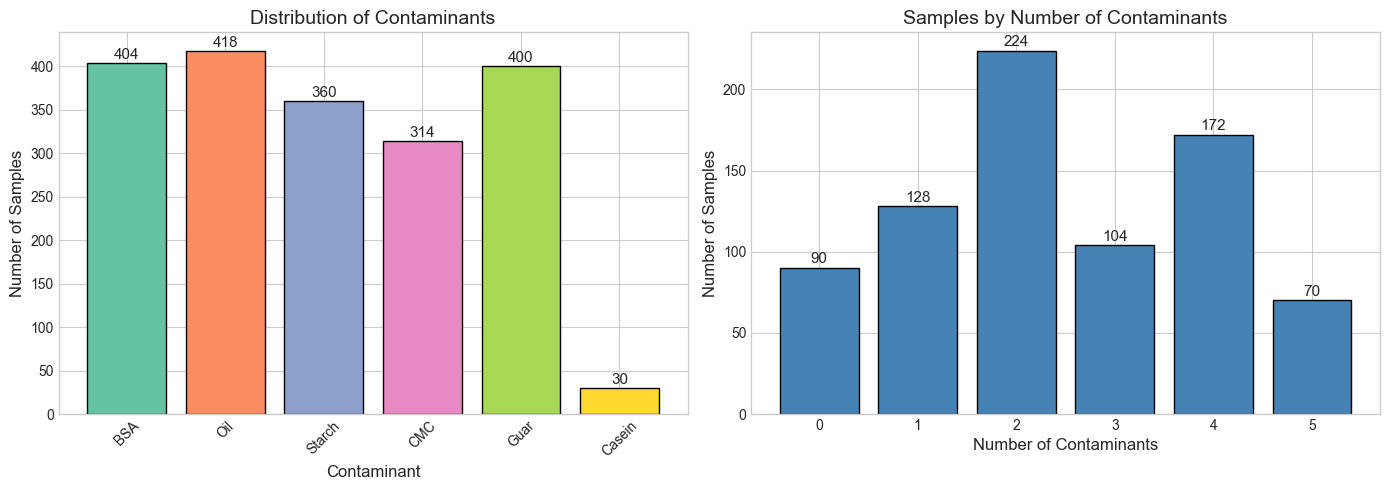

In [7]:
# Contaminant distribution
contaminant_counts = contaminant_labels.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for contaminants
colors = sns.color_palette('Set2', len(CONTAMINANTS))
bars = axes[0].bar(CONTAMINANTS, contaminant_counts, color=colors, edgecolor='black')
axes[0].set_xlabel('Contaminant', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Distribution of Contaminants', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, contaminant_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{int(count)}', ha='center', va='bottom', fontsize=11)

# Number of contaminants per sample
n_contaminants_per_sample = contaminant_labels.sum(axis=1)
unique, counts = np.unique(n_contaminants_per_sample, return_counts=True)

axes[1].bar([str(int(u)) for u in unique], counts, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Number of Contaminants', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Samples by Number of Contaminants', fontsize=14)
for i, (u, c) in enumerate(zip(unique, counts)):
    axes[1].text(i, c + 1, f'{c}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

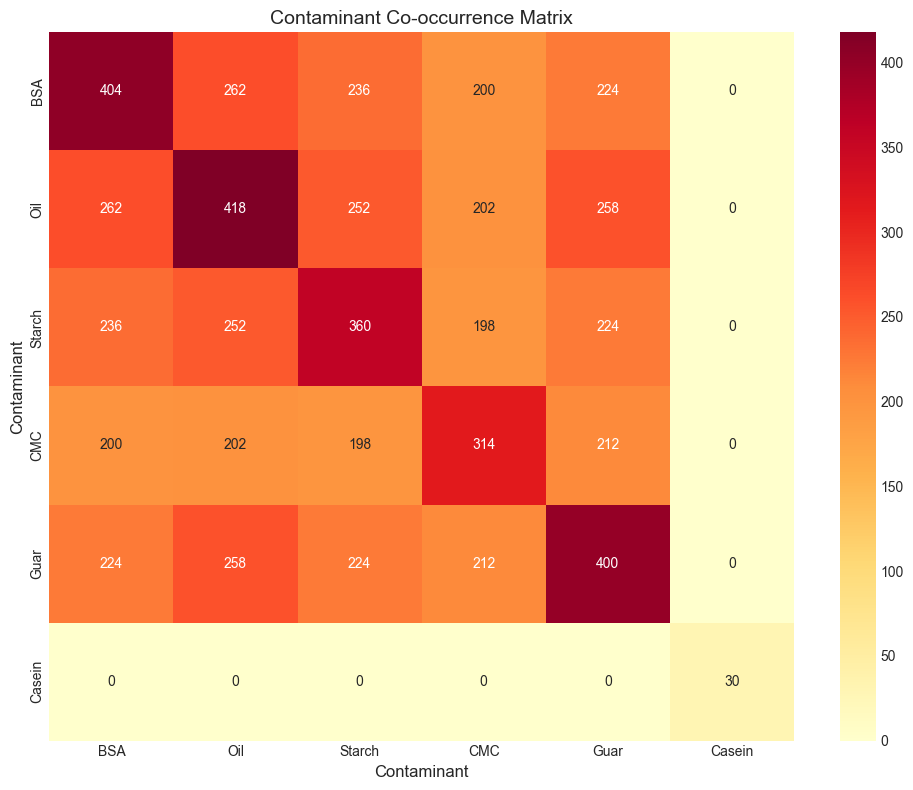

In [8]:
# Co-occurrence matrix for contaminants
co_occurrence = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)), dtype=int)
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        co_occurrence[i, j] = ((contaminant_labels[:, i] == 1) & 
                                (contaminant_labels[:, j] == 1)).sum()

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS)
plt.title('Contaminant Co-occurrence Matrix', fontsize=14)
plt.xlabel('Contaminant', fontsize=12)
plt.ylabel('Contaminant', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Spectral Visualization

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26260\692756344.py:21: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


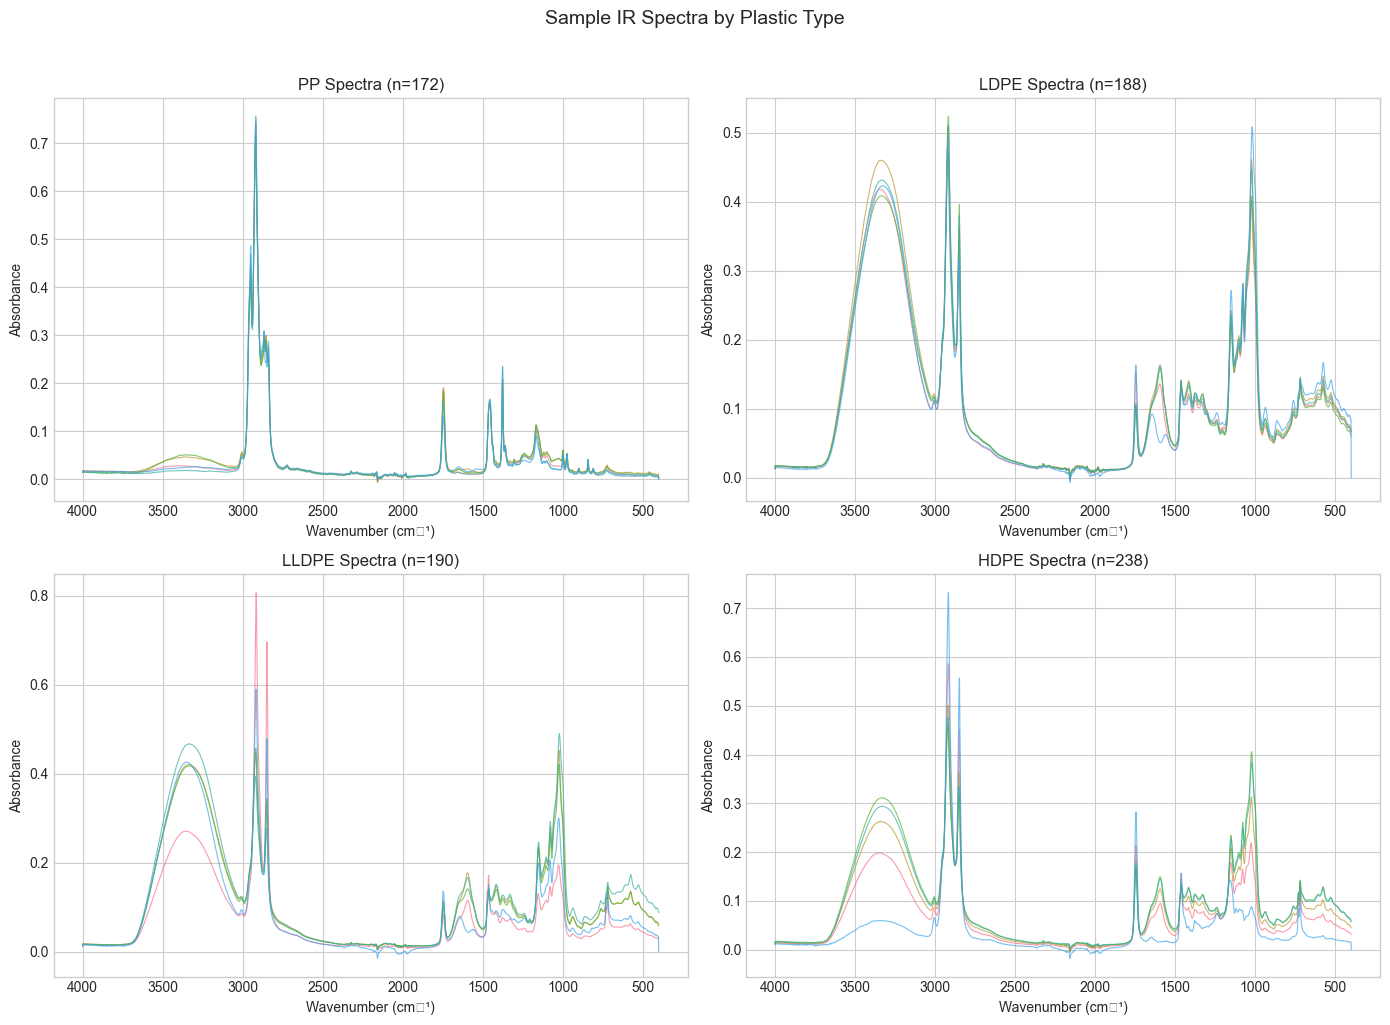

In [9]:
# Plot sample spectra for each plastic type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, plastic in enumerate(PLASTIC_TYPES):
    # Find samples of this plastic type
    mask = np.array(plastic_types) == plastic
    plastic_spectra = spectra[mask]
    
    # Plot up to 5 sample spectra
    n_samples = min(5, len(plastic_spectra))
    for i in range(n_samples):
        axes[idx].plot(wavenumbers, plastic_spectra[i], alpha=0.7, linewidth=0.8)
    
    axes[idx].set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    axes[idx].set_ylabel('Absorbance', fontsize=10)
    axes[idx].set_title(f'{plastic} Spectra (n={mask.sum()})', fontsize=12)
    axes[idx].invert_xaxis()  # IR convention: high to low wavenumber

plt.suptitle('Sample IR Spectra by Plastic Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26260\3694018634.py:19: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


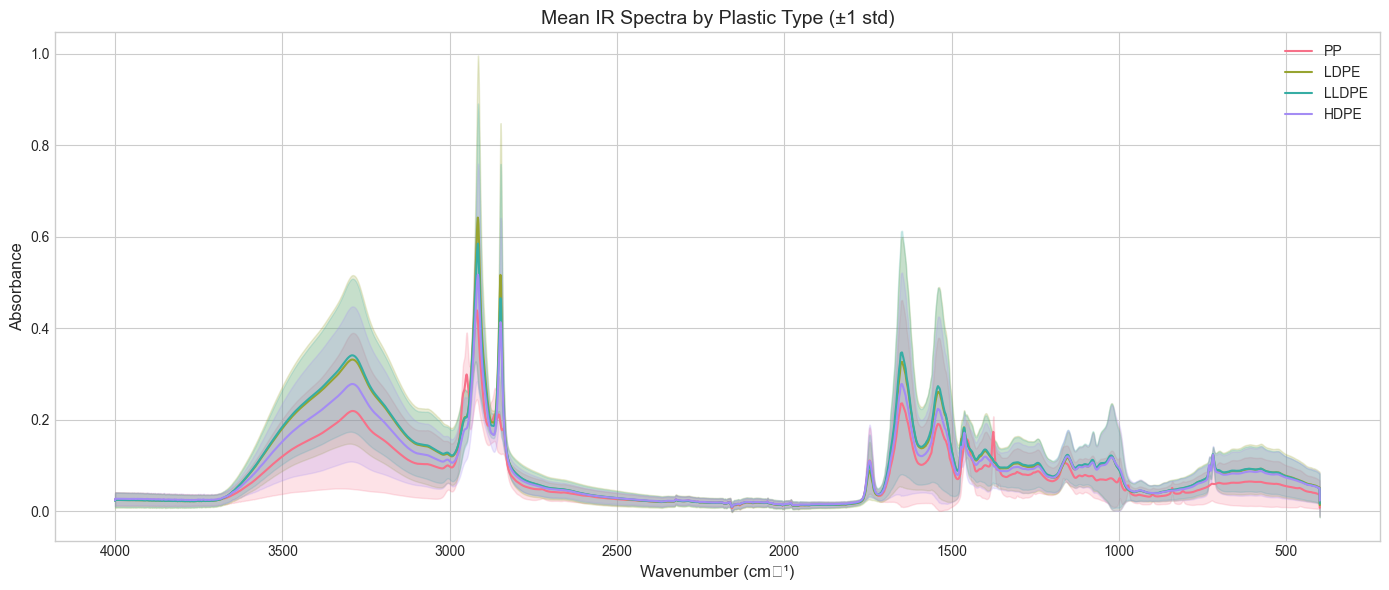

In [10]:
# Plot mean spectra for each plastic type
plt.figure(figsize=(14, 6))

colors = sns.color_palette('husl', len(PLASTIC_TYPES))
for idx, plastic in enumerate(PLASTIC_TYPES):
    mask = np.array(plastic_types) == plastic
    mean_spectrum = spectra[mask].mean(axis=0)
    std_spectrum = spectra[mask].std(axis=0)
    
    plt.plot(wavenumbers, mean_spectrum, label=plastic, color=colors[idx], linewidth=1.5)
    plt.fill_between(wavenumbers, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                     alpha=0.2, color=colors[idx])

plt.xlabel('Wavenumber (cm⁻¹)', fontsize=12)
plt.ylabel('Absorbance', fontsize=12)
plt.title('Mean IR Spectra by Plastic Type (±1 std)', fontsize=14)
plt.legend(loc='upper right')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26260\1365314874.py:23: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


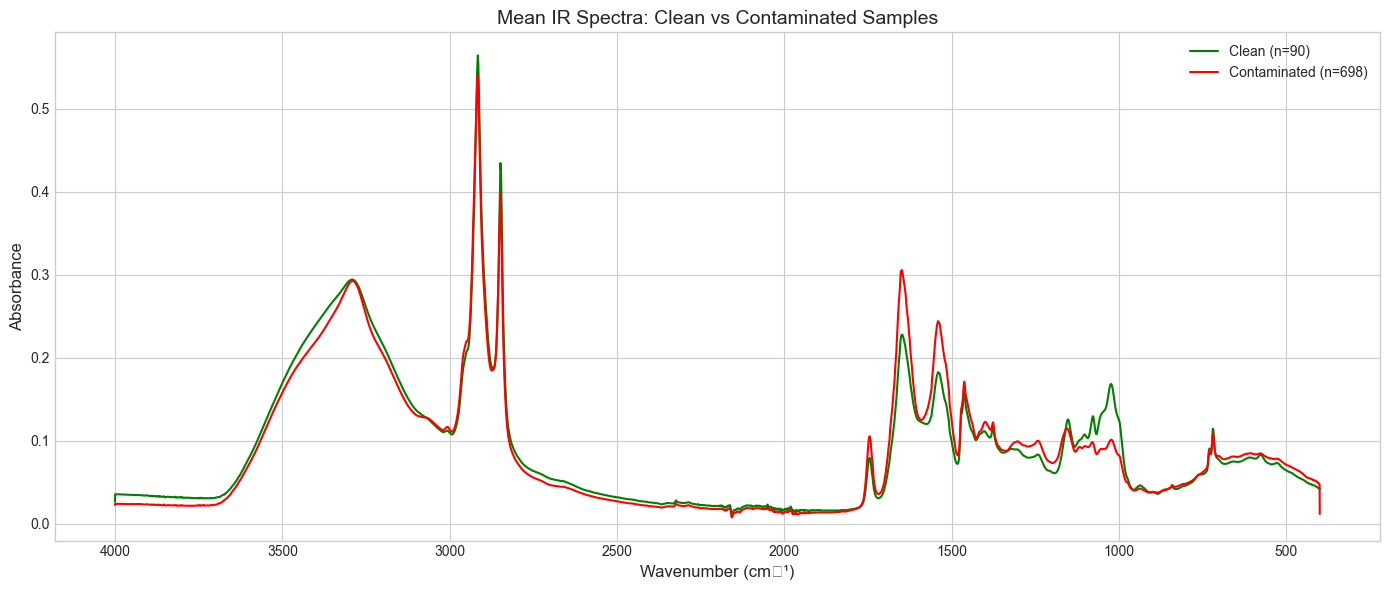

In [11]:
# Compare clean vs contaminated samples
n_contaminants_per_sample = contaminant_labels.sum(axis=1)
clean_mask = n_contaminants_per_sample == 0
contaminated_mask = n_contaminants_per_sample > 0

plt.figure(figsize=(14, 6))

if clean_mask.sum() > 0:
    mean_clean = spectra[clean_mask].mean(axis=0)
    plt.plot(wavenumbers, mean_clean, label=f'Clean (n={clean_mask.sum()})', 
             color='green', linewidth=1.5)

if contaminated_mask.sum() > 0:
    mean_contaminated = spectra[contaminated_mask].mean(axis=0)
    plt.plot(wavenumbers, mean_contaminated, label=f'Contaminated (n={contaminated_mask.sum()})', 
             color='red', linewidth=1.5)

plt.xlabel('Wavenumber (cm⁻¹)', fontsize=12)
plt.ylabel('Absorbance', fontsize=12)
plt.title('Mean IR Spectra: Clean vs Contaminated Samples', fontsize=14)
plt.legend(loc='upper right')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

## 4.1 Baseline Correction Comparison

Compare the effect of different baseline correction methods on the spectra:
- **Rubberband**: Convex hull-based correction, good for broad curved baselines
- **Polynomial**: Fits polynomial to local minima
- **ALS**: Asymmetric Least Squares, adaptive smoothing approach

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26260\3087261524.py:46: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


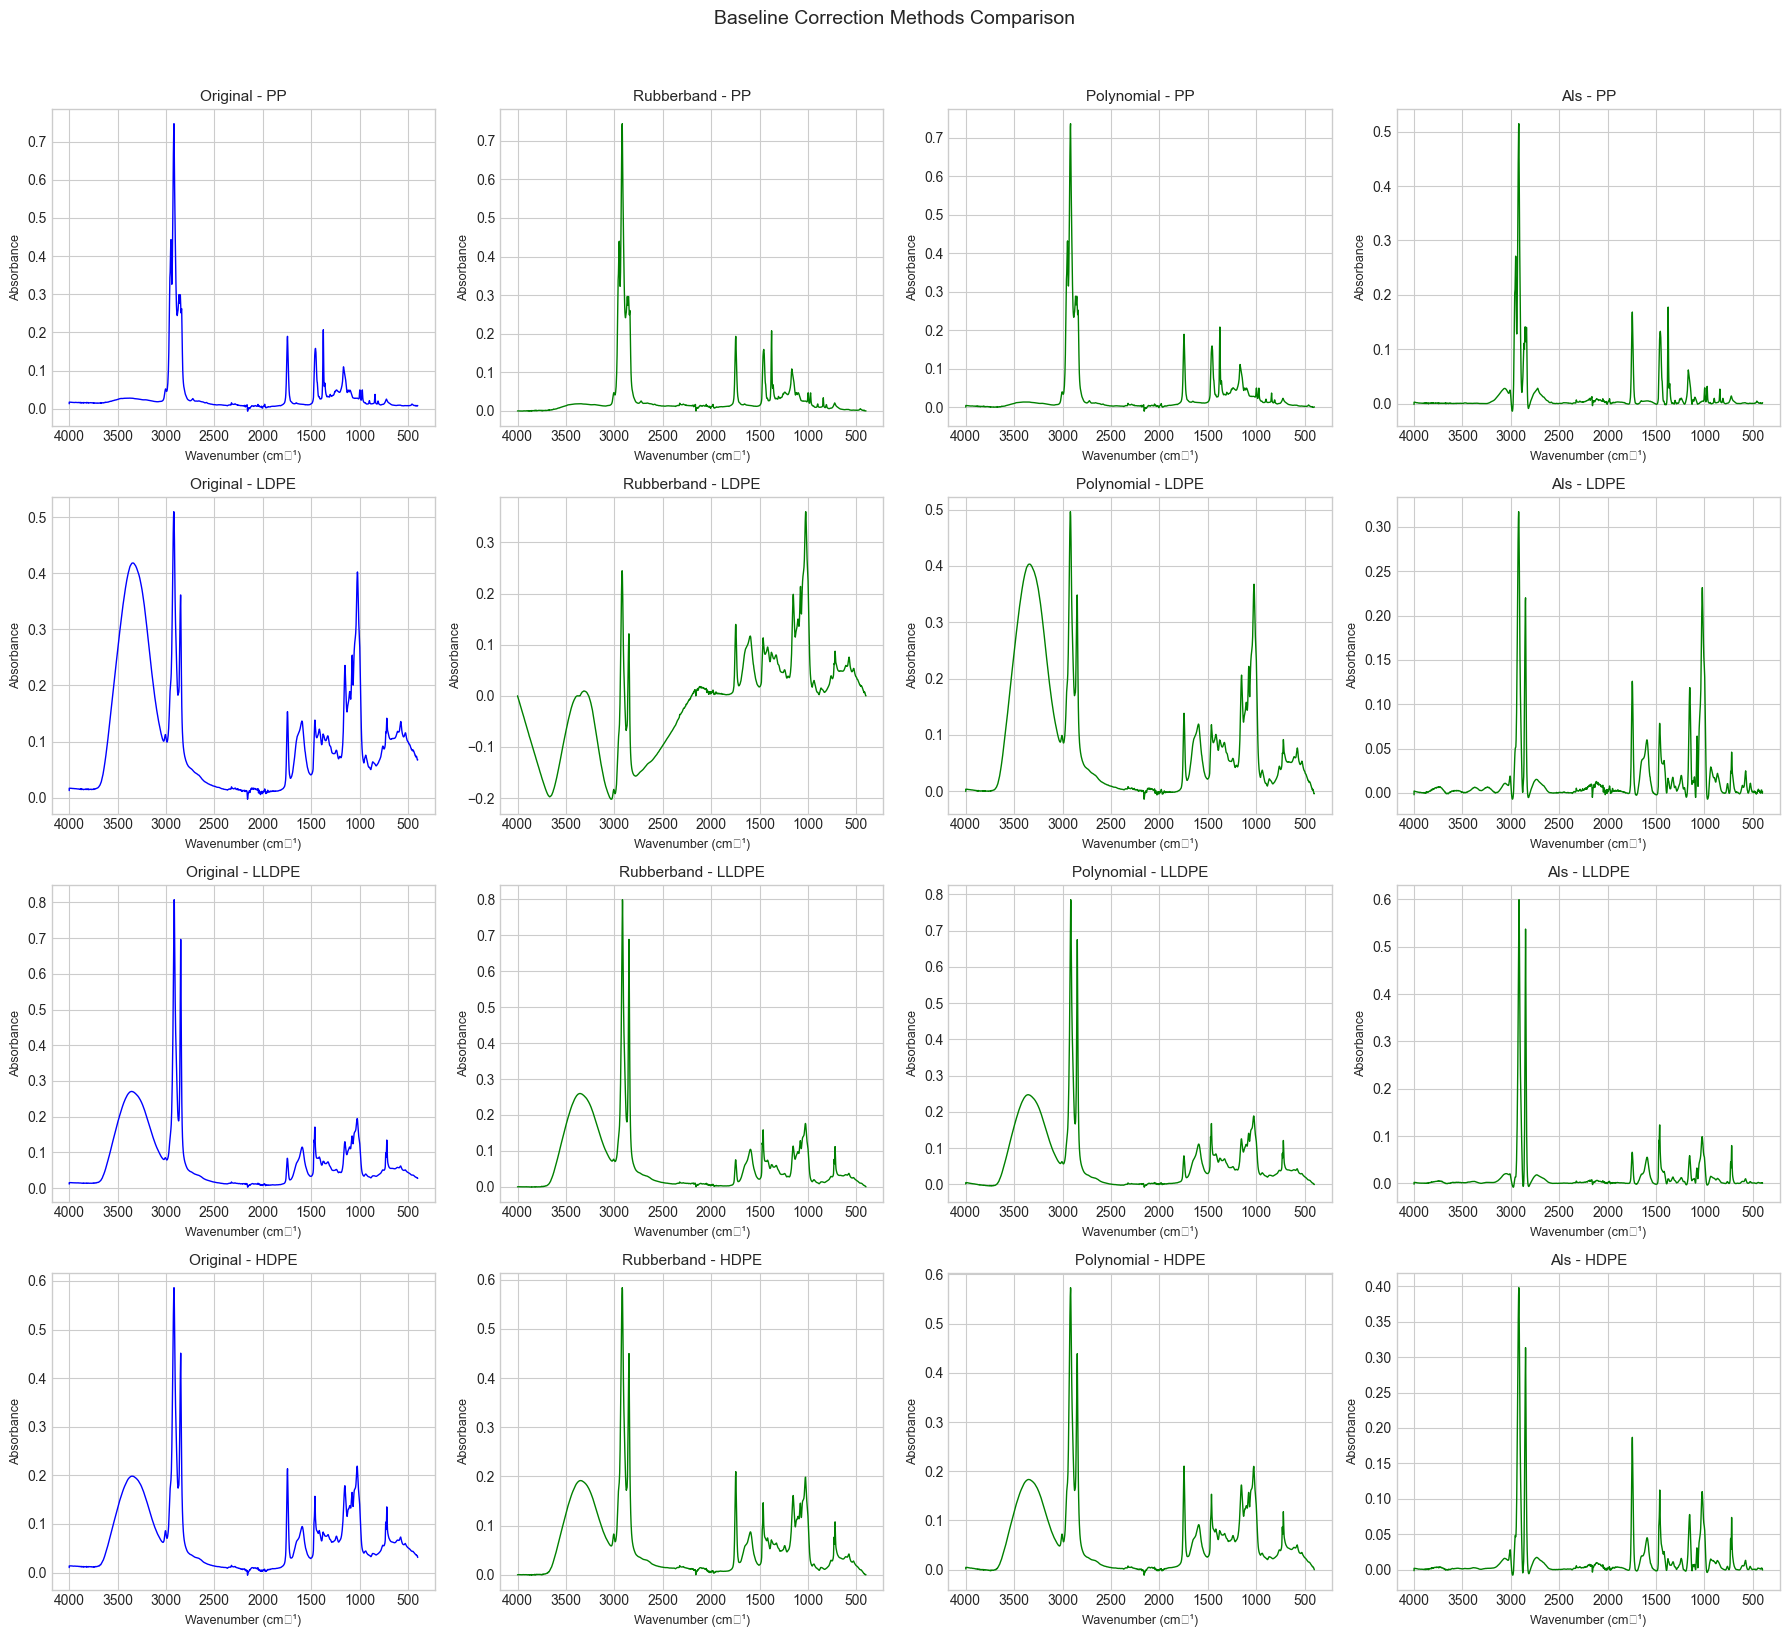

In [12]:
# Compare baseline correction methods on sample spectra
# Select a few representative spectra (one from each plastic type)
sample_indices = []
for plastic in PLASTIC_TYPES:
    mask = np.array(plastic_types) == plastic
    indices = np.where(mask)[0]
    if len(indices) > 0:
        sample_indices.append(indices[0])

# Apply each baseline correction method
methods = ['rubberband', 'polynomial', 'als']
method_params = {
    'rubberband': {},
    'polynomial': {'degree': 3},
    'als': {'lam': 1e6, 'p': 0.01}
}

# Create comparison plots
fig, axes = plt.subplots(len(sample_indices), len(methods) + 1, figsize=(18, 4 * len(sample_indices)))

for row, sample_idx in enumerate(sample_indices):
    original_spectrum = spectra[sample_idx]
    plastic = plastic_types[sample_idx]
    
    # Plot original spectrum
    axes[row, 0].plot(wavenumbers, original_spectrum, 'b-', linewidth=1)
    axes[row, 0].set_title(f'Original - {plastic}', fontsize=11)
    axes[row, 0].set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
    axes[row, 0].set_ylabel('Absorbance', fontsize=9)
    axes[row, 0].invert_xaxis()
    
    # Plot each baseline correction method
    for col, method in enumerate(methods, start=1):
        corrected = baseline_correction(
            wavenumbers, original_spectrum, 
            method=method, **method_params[method]
        )
        
        axes[row, col].plot(wavenumbers, corrected, 'g-', linewidth=1)
        axes[row, col].set_title(f'{method.capitalize()} - {plastic}', fontsize=11)
        axes[row, col].set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
        axes[row, col].set_ylabel('Absorbance', fontsize=9)
        axes[row, col].invert_xaxis()

plt.suptitle('Baseline Correction Methods Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26260\1956836369.py:37: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


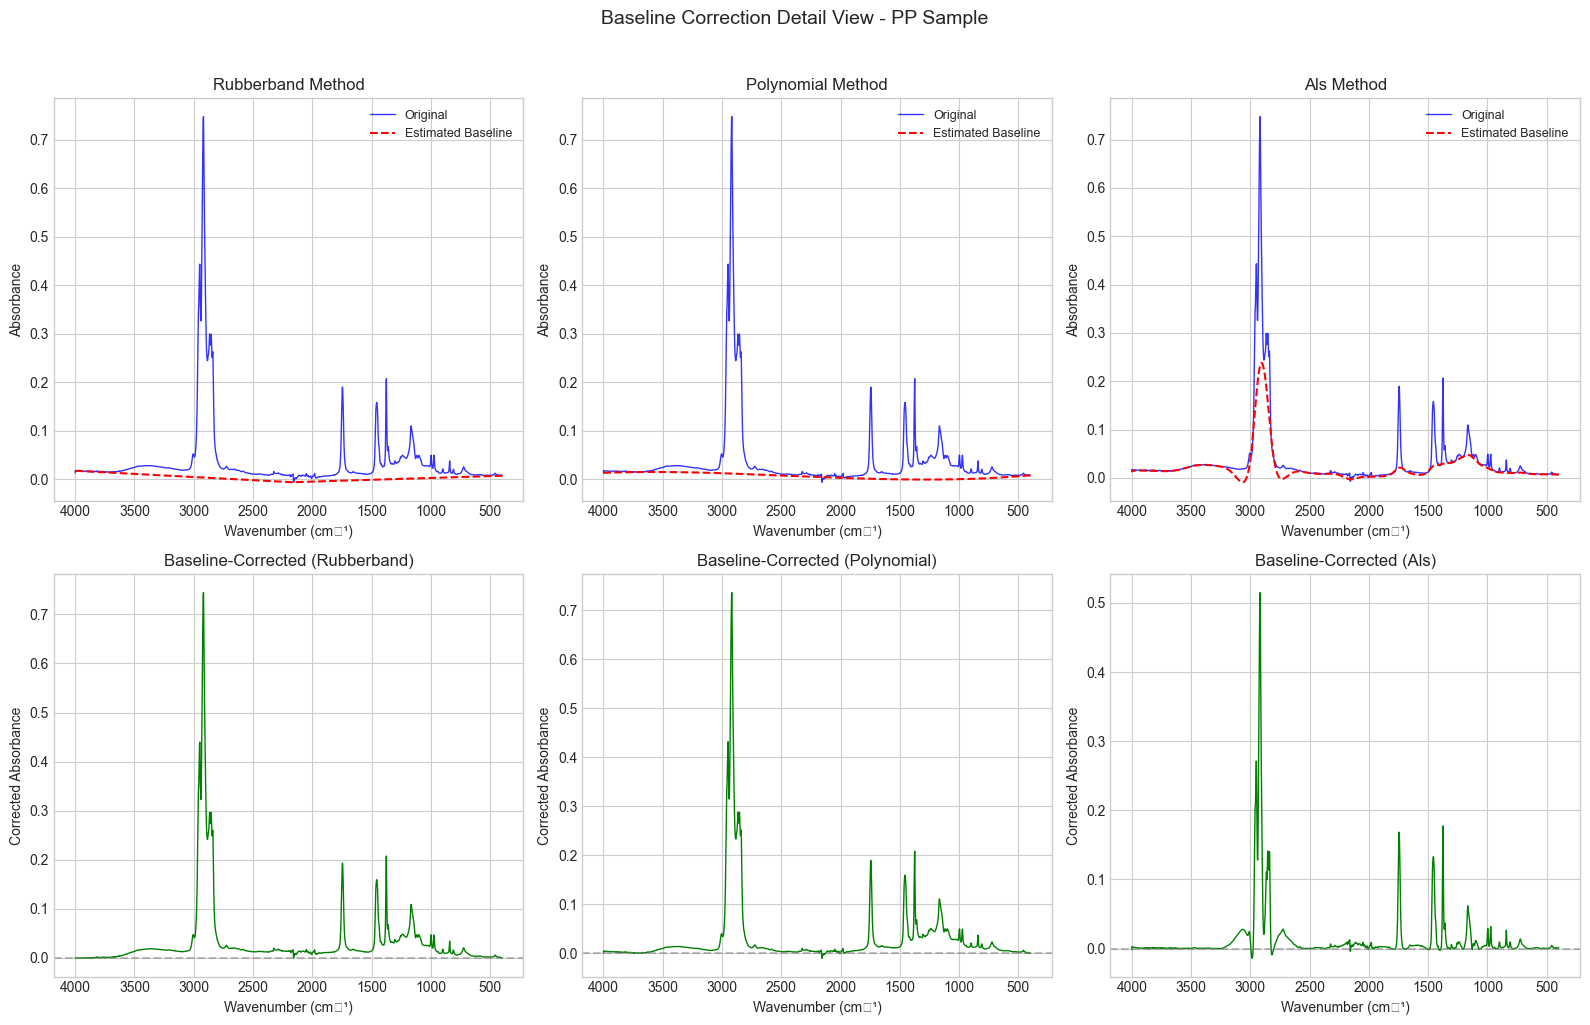


Baseline correction statistics for PP sample:
--------------------------------------------------
Rubberband  : min=-0.0007, max=0.7442, mean=0.0325, std=0.0748
Polynomial  : min=-0.0107, max=0.7359, mean=0.0288, std=0.0742
Als         : min=-0.0142, max=0.5148, mean=0.0131, std=0.0439


In [13]:
# Detailed comparison: Original vs Corrected with baseline overlay
# Pick one spectrum for detailed visualization
detail_idx = sample_indices[0]
original = spectra[detail_idx]
plastic = plastic_types[detail_idx]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, method in enumerate(methods):
    # Apply correction
    corrected = baseline_correction(
        wavenumbers, original, 
        method=method, **method_params[method]
    )
    
    # Calculate baseline (original - corrected)
    baseline = original - corrected
    
    # Top row: Original with baseline overlay
    axes[0, col].plot(wavenumbers, original, 'b-', linewidth=1, label='Original', alpha=0.8)
    axes[0, col].plot(wavenumbers, baseline, 'r--', linewidth=1.5, label='Estimated Baseline')
    axes[0, col].set_title(f'{method.capitalize()} Method', fontsize=12)
    axes[0, col].set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    axes[0, col].set_ylabel('Absorbance', fontsize=10)
    axes[0, col].legend(loc='upper right', fontsize=9)
    axes[0, col].invert_xaxis()
    
    # Bottom row: Corrected spectrum
    axes[1, col].plot(wavenumbers, corrected, 'g-', linewidth=1)
    axes[1, col].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1, col].set_title(f'Baseline-Corrected ({method.capitalize()})', fontsize=12)
    axes[1, col].set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    axes[1, col].set_ylabel('Corrected Absorbance', fontsize=10)
    axes[1, col].invert_xaxis()

plt.suptitle(f'Baseline Correction Detail View - {plastic} Sample', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBaseline correction statistics for {plastic} sample:")
print("-" * 50)
for method in methods:
    corrected = baseline_correction(wavenumbers, original, method=method, **method_params[method])
    print(f"{method.capitalize():12s}: min={corrected.min():.4f}, max={corrected.max():.4f}, "
          f"mean={corrected.mean():.4f}, std={corrected.std():.4f}")

## 5. Summary Statistics

In [14]:
# Spectral statistics
print("Spectral Statistics")
print("=" * 50)
print(f"Absorbance range: [{spectra.min():.6f}, {spectra.max():.6f}]")
print(f"Mean absorbance: {spectra.mean():.6f}")
print(f"Std absorbance: {spectra.std():.6f}")
print()

# Per-sample statistics
sample_means = spectra.mean(axis=1)
sample_stds = spectra.std(axis=1)
sample_maxs = spectra.max(axis=1)

print("Per-Sample Statistics")
print("=" * 50)
print(f"Mean of sample means: {sample_means.mean():.6f} ± {sample_means.std():.6f}")
print(f"Mean of sample stds: {sample_stds.mean():.6f} ± {sample_stds.std():.6f}")
print(f"Mean of sample maxs: {sample_maxs.mean():.6f} ± {sample_maxs.std():.6f}")

Spectral Statistics
Absorbance range: [-0.031580, 1.472108]
Mean absorbance: 0.089083
Std absorbance: 0.106385

Per-Sample Statistics
Mean of sample means: 0.089083 ± 0.037782
Mean of sample stds: 0.095404 ± 0.028080
Mean of sample maxs: 0.646629 ± 0.247614


In [15]:
# Create summary DataFrame
summary_data = []
for i, fname in enumerate(filenames):
    summary_data.append({
        'filename': fname,
        'plastic_type': plastic_types[i],
        'n_contaminants': int(contaminant_labels[i].sum()),
        'contaminants': ', '.join(contaminants_list[i]) if contaminants_list[i] else 'None',
        'mean_absorbance': spectra[i].mean(),
        'max_absorbance': spectra[i].max(),
        'std_absorbance': spectra[i].std()
    })

df_summary = pd.DataFrame(summary_data)
print(f"Summary DataFrame shape: {df_summary.shape}")
df_summary.head(10)

Summary DataFrame shape: (788, 7)


,filename,plastic_type,n_contaminants,contaminants,mean_absorbance,max_absorbance,std_absorbance
0,1203-54-2 pp-1.CSV,PP,0,None,0.035095,0.747256,0.074623
1,1203-54-2 pp-2.CSV,PP,0,None,0.039203,0.717296,0.071891
2,1203-54-3 LDPE-1.CSV,LDPE,0,None,0.107521,0.509622,0.112191
3,1203-54-3 LDPE-2.CSV,LDPE,0,None,0.116980,0.471779,0.121806
4,1203-54-3 LDPE-3.CSV,LDPE,0,None,0.108749,0.523525,0.111512
5,1203-54-3 LDPE-4.CSV,LDPE,0,None,0.112968,0.510607,0.116500
6,1203-54-4 LLDPE-1.CSV,LLDPE,0,None,0.077909,0.807221,0.093882
7,1203-54-4 LLDPE-2.CSV,LLDPE,0,None,0.112188,0.452762,0.113439
8,1203-54-5 LLDPE-1.CSV,LLDPE,0,None,0.109634,0.457268,0.111676
9,1203-54-5 LLDPE-2.CSV,LLDPE,0,None,0.120990,0.490031,0.123132


In [16]:
# Group statistics by plastic type
print("Statistics by Plastic Type")
print("=" * 60)
df_summary.groupby('plastic_type')[['mean_absorbance', 'max_absorbance', 'std_absorbance']].agg(['mean', 'std'])

Statistics by Plastic Type


mean_absorbance           max_absorbance            \
                        mean       std           mean       std   
plastic_type                                                      
HDPE                0.087266  0.035253       0.615010  0.205773   
LDPE                0.096605  0.039633       0.752714  0.289953   
LLDPE               0.097734  0.035306       0.694659  0.256706   
PP                  0.073819  0.037092       0.521372  0.164232   

             std_absorbance            
                       mean       std  
plastic_type                           
HDPE               0.090068  0.028211  
LDPE               0.108908  0.022031  
LLDPE              0.105761  0.021568  
PP                 0.076586  0.027747

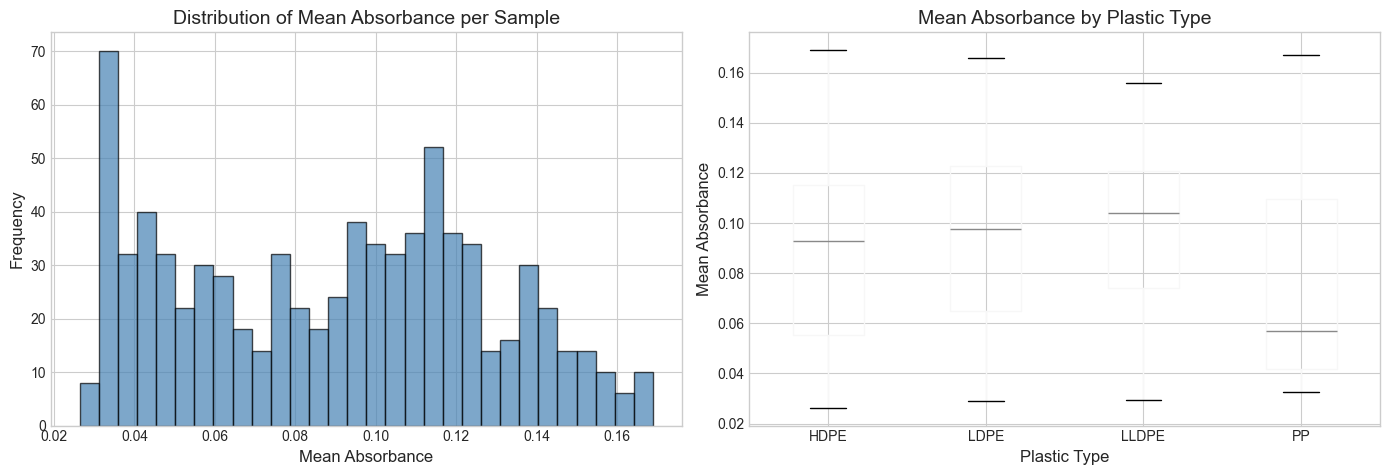

In [17]:
# Distribution of absorbance values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of mean absorbance per sample
axes[0].hist(sample_means, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Mean Absorbance', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Mean Absorbance per Sample', fontsize=14)

# Box plot by plastic type
df_summary.boxplot(column='mean_absorbance', by='plastic_type', ax=axes[1])
axes[1].set_xlabel('Plastic Type', fontsize=12)
axes[1].set_ylabel('Mean Absorbance', fontsize=12)
axes[1].set_title('Mean Absorbance by Plastic Type', fontsize=14)
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

In [18]:
print("\n" + "=" * 60)
print("INITIAL DATA ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nTotal samples: {len(filenames)}")
print(f"Spectral points per sample: {len(wavenumbers)}")
print(f"Wavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"\nPlastic types: {PLASTIC_TYPES}")
print(f"Contaminants: {CONTAMINANTS}")
print(f"\nClean samples: {(n_contaminants_per_sample == 0).sum()}")
print(f"Contaminated samples: {(n_contaminants_per_sample > 0).sum()}")


INITIAL DATA ANALYSIS COMPLETE

Total samples: 788
Spectral points per sample: 7469
Wavenumber range: 399.7 - 4000.2 cm⁻¹

Plastic types: ['PP', 'LDPE', 'LLDPE', 'HDPE']
Contaminants: ['BSA', 'Oil', 'Starch', 'CMC', 'Guar', 'Casein']

Clean samples: 90
Contaminated samples: 698
